# NVIDIA Stock Price Forecast for 8–12 June 2026


## 1.**Team Nickname:** [BUSLIK]

## 2.**Team Members:** [ANASTASIYA VIKHROVA] 


## 3. Forecasts

| 2026-06-08 | Monday | $204.26 |

| 2026-06-09 | Tuesday | $203.72 |

| 2026-06-10 | Wednesday | $203.29 |

| 2026-06-11 | Thursday | $202.91 |

| 2026-06-12 | Friday | $202.62 |


## 4. Method Description

We use an **ensemble of two models**: GBM-Regime and Momentum.

**GBM-Regime (Geometric Brownian Motion with Regime Detection)**  
Standard GBM models stock prices as a random process with drift μ and volatility σ.
Instead of using global parameters, we first detect the current *market regime*
(Bull / Sideways / Bear) using KMeans clustering on 20-day rolling volatility,
20-day rolling mean return, and VIX level. The current regime's μ and σ are then
used in a Monte Carlo simulation (10,000 paths), returning the median forecast.
This adapts the model to changing market conditions - after the June 5 shock,
the detected regime is *Sideways*, implying lower drift and higher uncertainty.

**Momentum**  
Computes the weighted average daily price change over the last 5 and 10 trading
days (70%/30%), projected forward with exponential decay so the trend gradually
fades rather than extrapolating indefinitely.

**Ensemble weights** are determined by inverse-MAE weighting from walk-forward
validation (15 rolling windows of 5 days). No manual tuning.

**Variables:** NVDA daily close price + ^VIX (CBOE Volatility Index), which measures how much uncertainty and fear investors feel about the next 30 days. It's calculated from options prices on the S&P 500 - when investors buy a lot of "insurance" against market drops, VIX goes up. Data is analyzed for last 6 months.


## 5. Code

In [8]:
# Install if needed:
# !pip install yfinance statsmodels scikit-learn numpy pandas matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import yfinance as yf

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

RANDOM_SEED    = 42
np.random.seed(RANDOM_SEED)

# Fixed dates up to June 6, 2026
START_DATE     = "2025-12-05"
END_DATE       = "2026-06-06"
FORECAST_DAYS  = 5
N_SIM          = 10_000
VAL_WINDOWS    = 15
WINDOW_SIZE    = 5
FORECAST_DATES = pd.bdate_range(start="2026-06-08", periods=FORECAST_DAYS)

print("Configuration:")
print(f"  Training data : {START_DATE} to {END_DATE}")
print(f"  Forecast dates: {[d.strftime('%Y-%m-%d') for d in FORECAST_DATES]}")

Configuration:
  Training data : 2025-12-05 to 2026-06-06
  Forecast dates: ['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12']


#### Data Download

In [9]:
nvda = yf.download("NVDA", start=START_DATE, end=END_DATE,
                   auto_adjust=True, progress=False)
vix  = yf.download("^VIX", start=START_DATE, end=END_DATE,
                   auto_adjust=True, progress=False)

for df in [nvda, vix]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

prices    = nvda["Close"].dropna()
vix_close = vix["Close"].dropna().rename("VIX")

print("Data loaded:")
print(f"  NVDA : {len(prices)} trading days  |  {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Last close : ${float(prices.iloc[-1]):.2f}")
print(f"  VIX        : {float(vix_close.iloc[-1]):.1f}")

log_ret = np.log(prices / prices.shift(1)).dropna()
print("\nRecent performance:")
for days, label in [(1,"1d"),(5,"5d"),(10,"10d"),(20,"20d"),(60,"60d")]:
    if len(prices) > days:
        chg = (float(prices.iloc[-1]) / float(prices.iloc[-days-1]) - 1) * 100
        sym = "UP" if chg > 0 else "DOWN"
        print(f"  {label:>4}: {sym} {chg:+.2f}%")

Data loaded:
  NVDA : 125 trading days  |  2025-12-05 to 2026-06-05
  Last close : $205.10
  VIX        : 21.5

Recent performance:
    1d: DOWN -6.20%
    5d: DOWN -2.75%
   10d: DOWN -6.46%
   20d: DOWN -2.91%
   60d: UP +10.38%


#### Model Definitions

In [10]:
def detect_regime(train_prices, vix_series, n_clusters=3):
    lr = np.log(train_prices / train_prices.shift(1)).dropna()
    features = pd.DataFrame({
        "vol_20": lr.rolling(20).std(),
        "ret_20": lr.rolling(20).mean(),
        "vix":    vix_series.reindex(lr.index).ffill(),
    }).dropna()
    if len(features) < n_clusters * 5:
        return lr.mean(), lr.std()
    sc     = StandardScaler()
    km     = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(sc.fit_transform(features))
    aligned = lr.iloc[-len(labels):]
    mu_r    = {r: aligned[labels == r].mean() for r in range(n_clusters)}
    sig_r   = {r: aligned[labels == r].std()  for r in range(n_clusters)}
    current = int(km.predict(sc.transform(features.iloc[[-1]]))[0])
    return mu_r[current], sig_r[current]


def model_gbm(train_prices, n_days, n_sim=N_SIM, seed=RANDOM_SEED):
    mu, sigma = detect_regime(train_prices, vix_close)
    S0  = float(train_prices.iloc[-1])
    rng = np.random.default_rng(seed)
    S   = np.full(n_sim, S0)
    out = np.zeros((n_sim, n_days))
    for t in range(n_days):
        Z        = rng.standard_normal(n_sim)
        S        = S * np.exp((mu - 0.5 * sigma**2) + sigma * Z)
        out[:, t] = S
    return np.median(out, axis=0)


def model_momentum(train_prices, n_days):
    mom5  = ((float(train_prices.iloc[-1]) - float(train_prices.iloc[-6]))  / 5
             if len(train_prices) >= 6  else 0)
    mom10 = ((float(train_prices.iloc[-1]) - float(train_prices.iloc[-11])) / 10
             if len(train_prices) >= 11 else 0)
    wm    = mom5 * 0.7 + mom10 * 0.3
    S0    = float(train_prices.iloc[-1])
    steps = np.arange(1, n_days + 1)
    decay = np.exp(-steps / n_days)
    return S0 + wm * steps * decay


# it shows current regime
mu_now, sigma_now = detect_regime(prices, vix_close)

lr_full  = np.log(prices / prices.shift(1)).dropna()
reg_feat = pd.DataFrame({
    "vol_20": lr_full.rolling(20).std(),
    "ret_20": lr_full.rolling(20).mean(),
    "vix":    vix_close.reindex(lr_full.index).ffill(),
}).dropna()
sc_v  = StandardScaler()
km_v  = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10)
lv    = km_v.fit_predict(sc_v.fit_transform(reg_feat))
means_v   = {r: lr_full.iloc[-len(lv):][lv == r].mean() for r in range(3)}
sr        = sorted(means_v, key=means_v.get)
rnames    = {sr[0]: "Bear", sr[1]: "Sideways", sr[2]: "Bull"}
cur_regime= rnames[int(km_v.predict(sc_v.transform(reg_feat.iloc[[-1]]))[0])]

print("Models defined: GBM-Regime + Momentum")
print("Current regime: " + cur_regime)
print("  mu    = " + str(round(mu_now * 100, 4)) + "%/day")
print("  sigma = " + str(round(sigma_now * 100, 4)) + "%/day")

Models defined: GBM-Regime + Momentum
Current regime: Sideways
  mu    = -0.2189%/day
  sigma = 2.7847%/day


#### Walk-Forward Validation

In [11]:
n       = len(prices)
min_tr  = 40
val_idx = np.linspace(min_tr, n - WINDOW_SIZE - 1, VAL_WINDOWS, dtype=int)

mae_gbm, mae_mom = [], []

for split in val_idx:
    tp = prices.iloc[:split]
    te = prices.iloc[split: split + WINDOW_SIZE].values
    if len(tp) < 30:
        continue
    try:
        fc_g = model_gbm(tp, WINDOW_SIZE)
        fc_m = model_momentum(tp, WINDOW_SIZE)
        mae_gbm.append(mean_absolute_error(te, fc_g))
        mae_mom.append(mean_absolute_error(te, fc_m))
    except:
        continue

avg_mae_gbm = np.mean(mae_gbm)
avg_mae_mom = np.mean(mae_mom)

w_gbm = (1.0 / avg_mae_gbm) / (1.0/avg_mae_gbm + 1.0/avg_mae_mom)
w_mom = (1.0 / avg_mae_mom) / (1.0/avg_mae_gbm + 1.0/avg_mae_mom)

print("Walk-Forward Validation (" + str(VAL_WINDOWS) + " windows x " + str(WINDOW_SIZE) + " days):")
print("  GBM-Regime : MAE = $" + str(round(avg_mae_gbm, 4)) + "  weight = " + str(round(w_gbm, 3)))
print("  Momentum   : MAE = $" + str(round(avg_mae_mom, 4)) + "  weight = " + str(round(w_mom, 3)))

Walk-Forward Validation (15 windows x 5 days):
  GBM-Regime : MAE = $7.9256  weight = 0.426
  Momentum   : MAE = $5.8813  weight = 0.574


### Final Forecast

In [12]:
fc_gbm = model_gbm(prices, FORECAST_DAYS)
fc_mom = model_momentum(prices, FORECAST_DAYS)

final_forecast = w_gbm * fc_gbm + w_mom * fc_mom

days_v   = np.arange(1, FORECAST_DAYS + 1)
upper_95 = float(prices.iloc[-1]) * np.exp( 1.96 * sigma_now * np.sqrt(days_v))
lower_95 = float(prices.iloc[-1]) * np.exp(-1.96 * sigma_now * np.sqrt(days_v))

print("=" * 55)
print("  FINAL FORECASTS — NVDA CLOSING PRICE (USD)")
print("  Model  : GBM-Regime + Momentum")
print("  Regime : " + cur_regime + "  |  VIX: " + str(round(float(vix_close.iloc[-1]), 1)))
print("=" * 55)

final_results = {}
for i, date in enumerate(FORECAST_DATES):
    pval = round(float(final_forecast[i]), 2)
    lo   = round(float(lower_95[i]), 2)
    hi   = round(float(upper_95[i]), 2)
    day  = date.strftime("%A")
    ds   = date.strftime("%Y-%m-%d")
    print("  " + ds + " (" + day + "): $" + str(pval) +
          "   [95% CI: $" + str(lo) + " - $" + str(hi) + "]")
    final_results[ds] = pval

print("=" * 55)
last_price = float(prices.iloc[-1])
move = float(final_forecast[-1]) - last_price
print("  Last close (" + str(prices.index[-1].date()) + "): $" + str(round(last_price, 2)))
print("  Expected 5-day move: $" + str(round(move, 2)) +
      " (" + str(round(move / last_price * 100, 2)) + "%)")

  FINAL FORECASTS — NVDA CLOSING PRICE (USD)
  Model  : GBM-Regime + Momentum
  Regime : Sideways  |  VIX: 21.5
  2026-06-08 (Monday): $204.26   [95% CI: $194.21 - $216.61]
  2026-06-09 (Tuesday): $203.72   [95% CI: $189.86 - $221.56]
  2026-06-10 (Wednesday): $203.29   [95% CI: $186.6 - $225.44]
  2026-06-11 (Thursday): $202.91   [95% CI: $183.89 - $228.76]
  2026-06-12 (Friday): $202.62   [95% CI: $181.54 - $231.72]
  Last close (2026-06-05): $205.1
  Expected 5-day move: $-2.48 (-1.21%)


### Observations and intuition

Looking at NVDA price history, we can identify a clear pattern:

- **March 2026:** Sharp drop from ~176 USD to ~165 USD (-6.3%). Price recovered 
  to 202 dol within 3 weeks, finding strong support level around the **196-210 USD zone** for last 2 months.(a price at which a stock tends to stop falling and bounce back up, because many investors think "this is cheap, I'll buy now" and those buyers create demand that stops the price from falling further like a floor).

- **April/May 2026:** Another significant drop from 216 USD to 196 USD (-9.3%), 
  followed by a V-shape rebound all the way to $235 in just 10 days (+19%).

- **June 5, 2026:** Sharp drop -6.2% (close: 205.10 USD). Importantly, this was 
  not NVDA-specific - AMD and semiconductor ETFs (SOXX) fell on the same day, 
  indicating a **broad sector-level shock**, not company-specific bad news.

**Conclusion:** The 196-210 USD zone has acted as strong support multiple times.
The current price (205.10 USD) sits right at this level. Based on historical behavior,
we expect **consolidation around 202-205 USD** in the coming week, consistent with
our GBM-Regime + Momentum forecast.

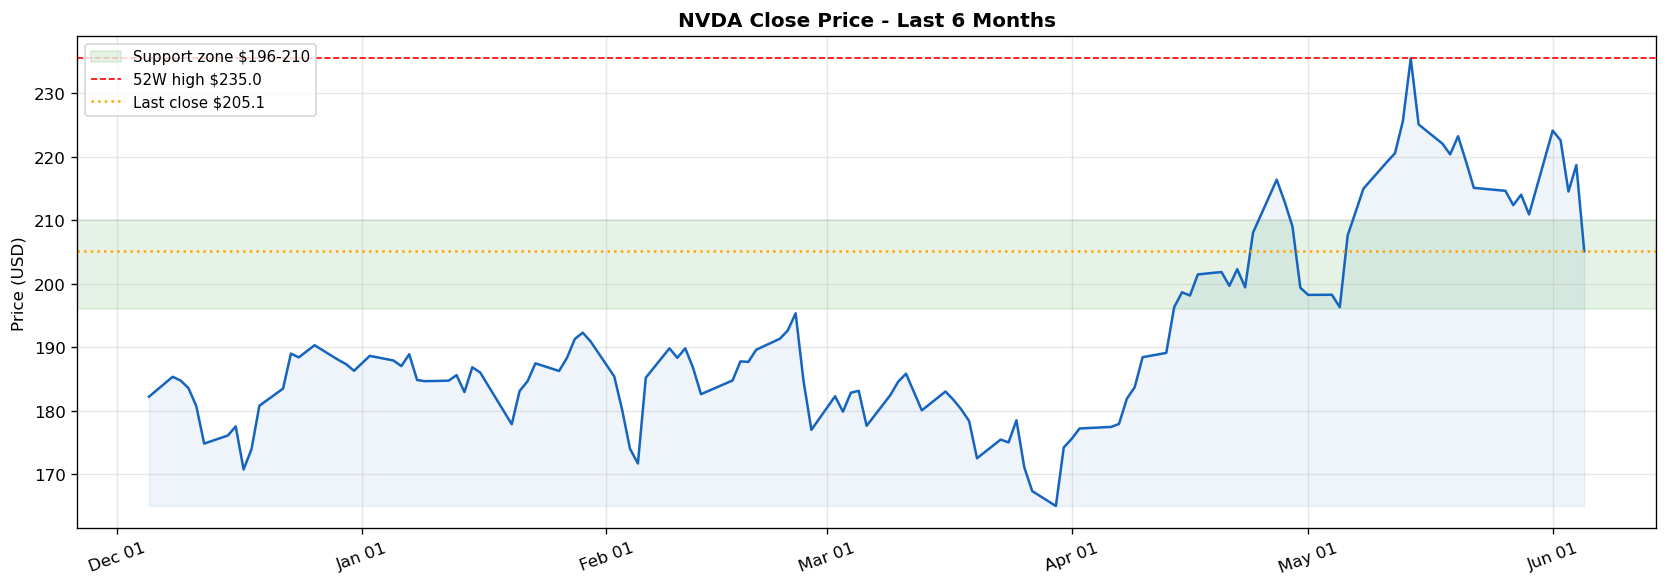

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prices.index, prices.values, color="#1565C0", linewidth=1.5)
ax.fill_between(prices.index, prices.values, float(prices.min()),
                alpha=0.07, color="#1565C0")

ax.axhspan(196, 210, alpha=0.1, color="green",
           label="Support zone $196-210")
ax.axhline(float(prices.max()), color="red", linestyle="--",
           linewidth=1, label="52W high $" + str(round(float(prices.max()), 0)))
ax.axhline(float(prices.iloc[-1]), color="orange", linestyle=":",
           linewidth=1.5, label="Last close $" + str(round(float(prices.iloc[-1]), 2)))

ax.set_title("NVDA Close Price - Last 6 Months", fontweight="bold", fontsize=12)
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()